# Anomaly Detection
### 1. Importing and Exploring the Dataset  
- Data types: Check for numerical, categorical, and ordinal features.
- Missing values: Check for missing data
- Use .info() and .describe()
- Plot data frequency with histograms

> NO split into x_train and x_validation

2. Data Preprocessing (Handling Missing Data)  
> **SimpleImputer or KNNImputer for numerical columns, SimpleImputer for categorical columns**.  
- Numerical columns: Impute using SimpleImputer (median) or KNNImputer.  
- Categorical columns: Impute using SimpleImputer with ‘most_frequent’ or ‘unknown’.  
- Drop Constant Columns: If a column has only one unique value, it won’t contribute to the anomaly detection, so drop it.  
###### For anomaly detection, though, you’ll likely want to impute rather than drop rows, since missing data could be an anomaly in itself.  

### 3. Feature Engineering and Transformation  
- **Scale numerical data**: If using algorithms that are distance-based (like KNN), you should scale your numerical columns using StandardScaler or MinMaxScaler.
- Categorical Encoding: use either OneHotEncoder.
- Ordinal Columns: OrdinalEncoder.

### Pretty standard until here :)

### 4. Use anomaly detection model  
- Local outlier factor  
    - get anomaly labels
    - anomaly score: - LocalOutlierFactor.negative_outlier_factor_
    - plot sorted anomaly score to undersand the contamination (before suppose 5%)

- Isolation Forest  
    - get anomaly labels
    - anomaly score: - IsolationForest.score_samples()
    - plot sorted anomaly score to undersand the contamination (before suppose 5%)

- One-Class SVM  
    - get anomaly labels
    - anomaly score: - OneClassSVM.decision_function()
    - plot sorted anomaly score to undersand the contamination (before suppose 5%)

- KNN-based Anomaly Detection
    - anomaly score: compute distance to closest centroid + pick values with highest distance --> flag as anomalous
    - plot sorted anomaly score to undersand the contamination (before suppose 5%)

### 5. Evaluation
- if you actually know which are anomalies:
    - those rows the model flagged as anomalous --> create a new df column and set them to 1
    - then use **classification_report**
        - precision
        - recall
        - F1-score

- **IF YOU DO NOT**:
    - get the anomalous data
    - plot it --> often we are in more than 2D --> **PCA AND THEN PLOT**

    - use more than one AD model, flag the found anomalous data with a new DF column and set it to 1 for anomalous data
    - compare all the flags

### 6. Post-Processing  
- after detecting anomalies, you can investigate them manually  

---

In [18]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.neighbors import LocalOutlierFactor
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM

from sklearn.decomposition import PCA

In [2]:
train_path = '/Users/filippomontecchi/Desktop/Data Science & Machine Learning Lab/Lab/Code/CORE_CODING/clustering + anomaly detection/toy_dataset/anomaly_detection_dataset.csv'
train_df= pd.read_csv(train_path)
train_df

,num_1,num_2,ord_1,ord_2,cat_1,cat_2
0,1.263678,-12.169996,High,Medium,Blue,Red
1,-7.937483,4.691052,Medium,High,Green,Red
2,-5.878989,-1.411118,Medium,High,Red,Red
3,14.530511,-3.520373,High,Low,Red,Green
4,20.213161,7.399146,Medium,High,Red,Green
...,...,...,...,...,...,...
995,0.619372,6.434781,Low,High,Green,Red
996,10.974306,-10.985677,Low,Medium,Red,Blue
997,-0.209044,-6.099576,High,High,Blue,Red
998,-12.489301,-0.518392,High,Low,Red,Blue


In [3]:
train_df.describe()

,num_1,num_2
count,860.000000,1000.000000
mean,0.753988,0.058005
std,15.565224,9.388807
min,-107.750346,-29.309312
25%,-6.741007,-6.371765
50%,-0.104501,0.033139
75%,7.127233,6.003550
max,117.995011,31.843066


In [4]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   num_1   860 non-null    float64
 1   num_2   1000 non-null   float64
 2   ord_1   850 non-null    object 
 3   ord_2   1000 non-null   object 
 4   cat_1   850 non-null    object 
 5   cat_2   1000 non-null   object 
dtypes: float64(2), object(4)
memory usage: 47.0+ KB


In [5]:
train_df.isna().mean().sort_values(ascending=False)*100

ord_1    15.0
cat_1    15.0
num_1    14.0
num_2     0.0
ord_2     0.0
cat_2     0.0
dtype: float64

- low nan values --> impute

In [6]:
mask = train_df.isna().mean(axis=1).sort_values(ascending=False)*100 >= 50

train_df[mask]

/var/folders/rm/3824k2x54sq3nnxhl4gs11mc0000gn/T/ipykernel_10707/3237168520.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  train_df[mask]


,num_1,num_2,ord_1,ord_2,cat_1,cat_2
5,NaN,-4.763536,NaN,Medium,NaN,Blue
10,NaN,12.319841,NaN,Medium,NaN,Blue
22,NaN,2.316802,NaN,Medium,NaN,Red
37,NaN,-4.681512,NaN,High,NaN,Red
44,NaN,-14.373932,NaN,High,NaN,Green
...,...,...,...,...,...,...
946,NaN,4.577706,NaN,Medium,NaN,Red
961,NaN,9.355295,NaN,High,NaN,Green
963,NaN,-7.254528,NaN,High,NaN,Green
972,NaN,0.745285,NaN,Low,NaN,Red


- 140 rows with 50% missing values
- not even a question, in anomaly detection impute!

- look at distributions

In [7]:
num_col = train_df.loc[:,'num_1':'num_2']
ord_col = train_df.loc[:,'ord_1':'ord_2']
cat_col = train_df.loc[:,'cat_1':'cat_2']

In [8]:
num_col.shape

(1000, 2)

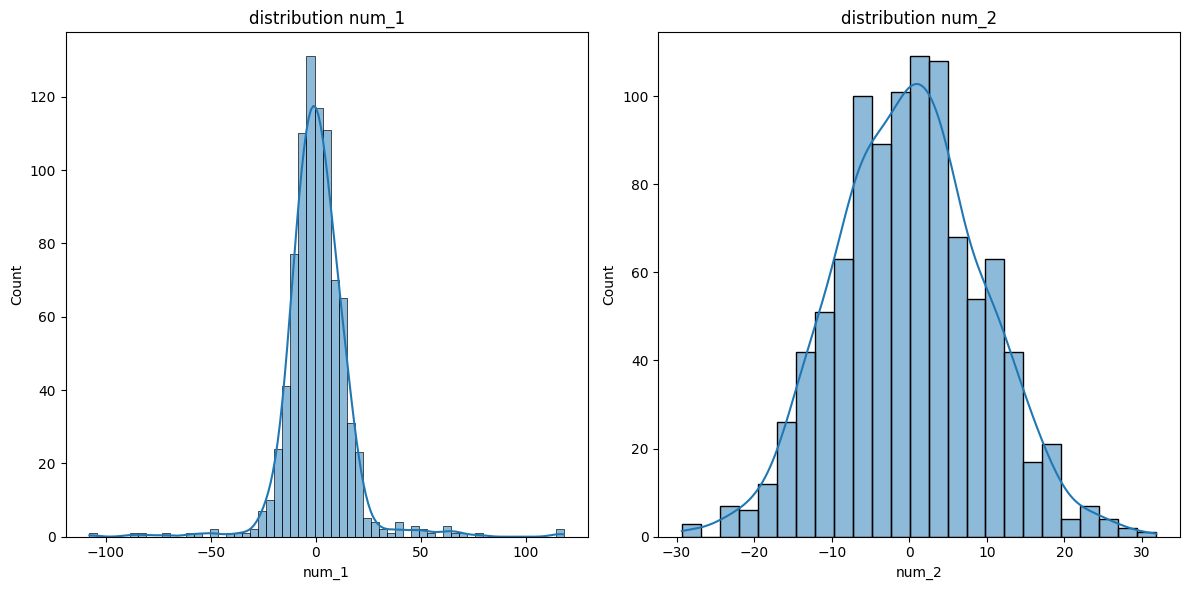

In [9]:
plt.figure(figsize=(12,6))
for plt_idx, n_c in enumerate(num_col):
    plt.subplot(1,2,plt_idx+1)
    sns.histplot(x=num_col[n_c], bins='auto', kde=True)
    plt.title(f"distribution {n_c}")

plt.tight_layout()
plt.show()

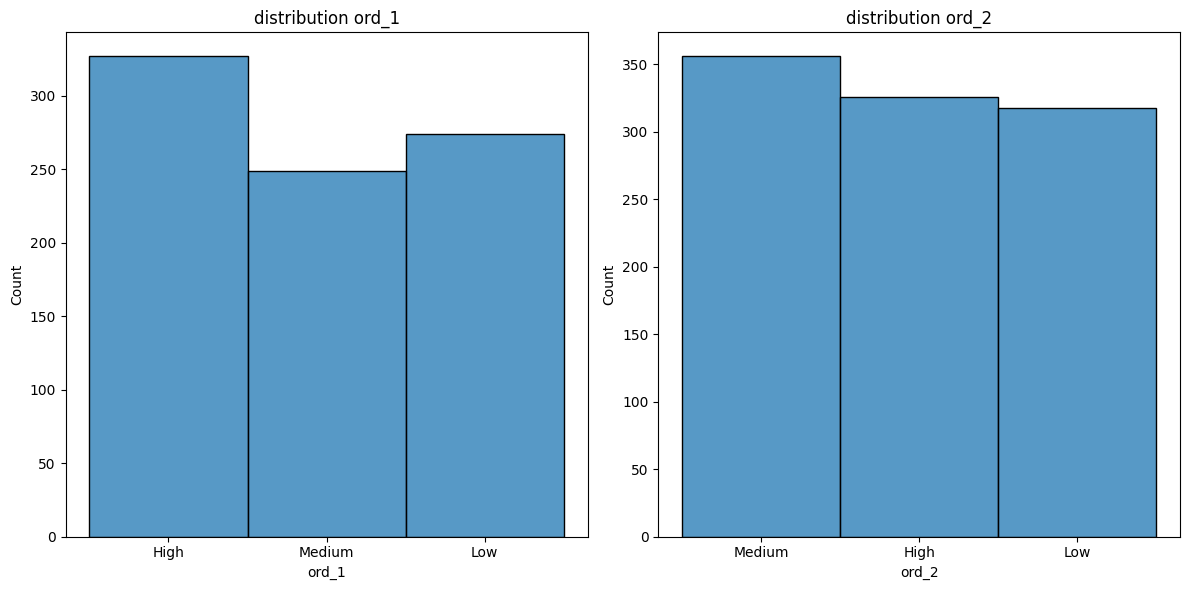

In [10]:
plt.figure(figsize=(12,6))
for plt_idx, col in enumerate(ord_col):
    plt.subplot(1,2,plt_idx+1)
    sns.histplot(x=ord_col[col], bins='auto', kde=False)
    plt.title(f"distribution {col}")

plt.tight_layout()
plt.show()

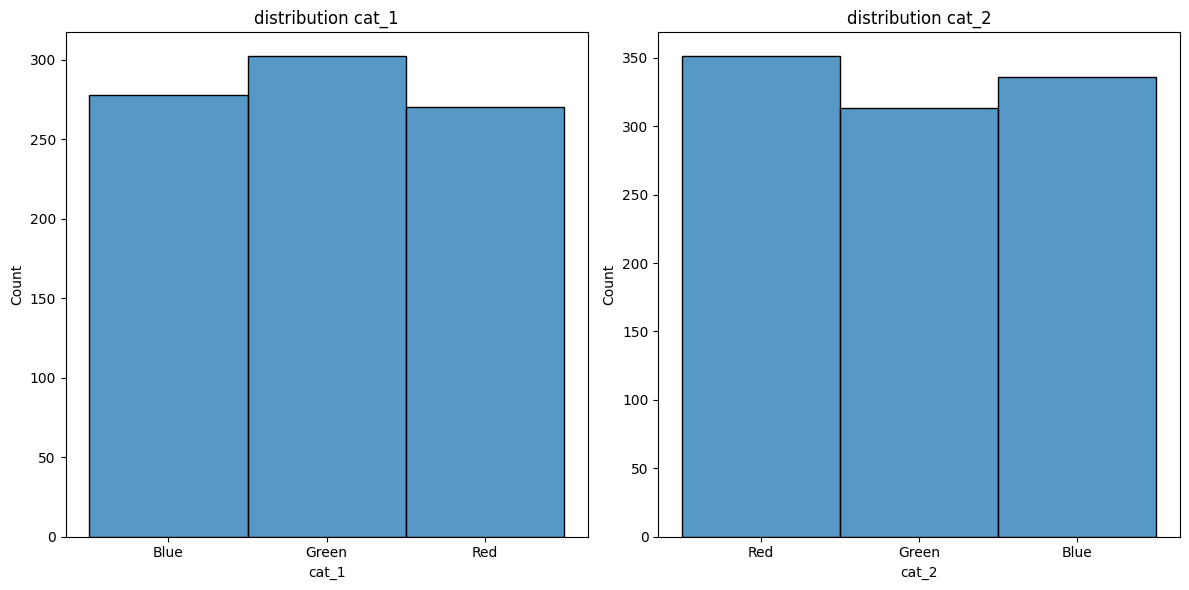

In [11]:
plt.figure(figsize=(12,6))
for plt_idx, col in enumerate(cat_col):
    plt.subplot(1,2,plt_idx+1)
    sns.histplot(x=cat_col[col], bins='auto', kde=False)
    plt.title(f"distribution {col}")

plt.tight_layout()
plt.show()

- distributions are fine

- no weird nan-like values

- get ordinal values

In [12]:
for col in ord_col:
    non_nan_mask = ord_col[col].notna()
    ord_values = ord_col[col][non_nan_mask].unique()
    
# manually build the categories, one list per column
ordinal_values = [
    ['High' 'Medium' 'Low'],
    ['High' 'Medium' 'Low']
]


> Preprocessing  

num_1, num_2 --> simplimpute median --> standardscaler --> IF YOU USE A RANDOMFOREST ISOLATION DON'T SCALE  
ord_1, ord_2 --> simpleimpute constant 'unknown' --> ordinal encoder (map 'unknown' to -1 + pass classes + map categorical missing values to -2)  
cat_1, cat_2 --> simpleimpute constant 'unknown' --> one hot encoder  

In [13]:
num_col_names = num_col.columns.tolist()
ord_col_names = ord_col.columns.tolist()
cat_col_names = cat_col.columns.tolist()

In [14]:
num_pipe = Pipeline(steps=[
    (
        'num_imputer',
        SimpleImputer(strategy='median', add_indicator=True)
    )
    ,
    (
        'scaler',
        StandardScaler()
    )
])


ord_pipe = Pipeline(steps=[
    (
        'ord_imputer',
        SimpleImputer(strategy='constant', fill_value='unknown')    # add_indicator=True
    )
    ,
    (
        'OE',
        OrdinalEncoder(categories=ordinal_values, handle_unknown='use_encoded_value', unknown_value=-1, encoded_missing_value=-2)
    )
])


cat_pipe = Pipeline(steps=[
    (
        'cat_imputer',
        SimpleImputer(strategy='constant', fill_value='unknown', add_indicator=True)
    )
    ,
    (
        'OHE',
        OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    )
])


preprocessing_pipeline = ColumnTransformer(transformers=[
    ('num_prep', num_pipe, num_col_names),
    ('ord_prep', ord_pipe, ord_col_names),
    ('cat_prep', cat_pipe, cat_col_names)
], remainder='passthrough', n_jobs=-1)


prep_train_df = preprocessing_pipeline.fit_transform(train_df)
prep_train_df.shape



(1000, 14)

----

# IMPORTANT
- before it was pretty standard

1. Run one AD model --> get labels + anomaly score  
2. Build new column that flags with 1 the suspected anomaly points  
3. Plot sorted anomaly score to have an idea of contamination (otherwise assume 0.05)
4. Plot normal vs anomalous data --> the data is probably in more than 2D --> **PCA AND PLOT**
5. Try also other algorithms  

- get anomaly score and flag anomalous data with a new column and flag them to 1

In [15]:
# I'm assuming contamination 5%
contamination = 0.05

LOF = LocalOutlierFactor(n_neighbors=20, n_jobs=-1, contamination=0.05)
labels = LOF.fit_predict(prep_train_df)

# spot anomalous data
anomaly_mask = labels == -1
normal_mask = labels == 1
anomaly_data = train_df.iloc[anomaly_mask, :]
normal_data = train_df.iloc[normal_mask, :]
display(anomaly_data, normal_data)

# get anomalous score
anomaly_score = - LOF.negative_outlier_factor_  # the higher the more anomalous
anomaly_score = np.sort(anomaly_score)[::-1]

# flag suspected anomalous data in a new column
train_df['LOF_anomaly'] = (labels == -1).astype(int)


- plot the anomaly score to see if the anomalous data could you actually be 5%

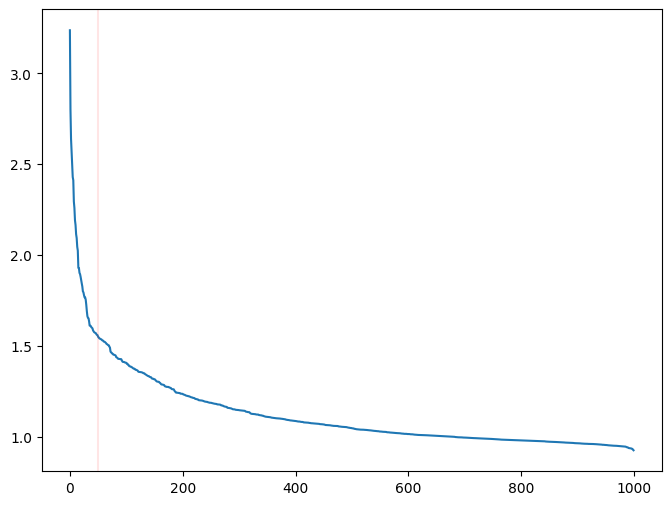

In [17]:
plt.figure(figsize=(8,6))
plt.plot(anomaly_score)
plt.axvline(x=50, alpha=0.1, c='red')
plt.show()

###### holy shit it could actually be!

- it would be ideal to plot these points and see if they actually stand out but data is actually 7D ...
# - REDUCE DIMENSIONALITY TO 2D WITH PCA AND PLOT POINTS
- pass it the already preprocessed DF

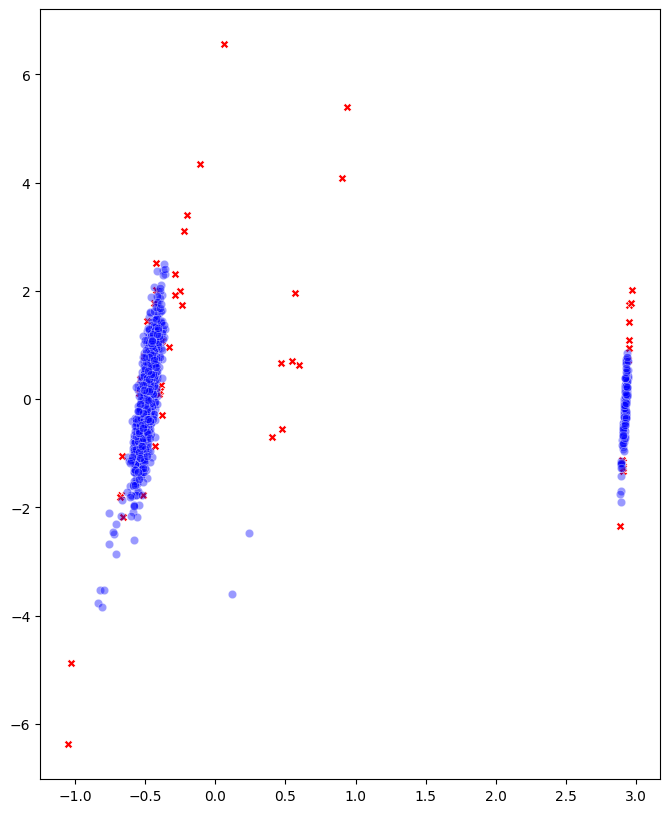

In [24]:
pca = PCA(n_components=2, random_state=42)
pca_2d_data = pca.fit_transform(prep_train_df)

anomaly_idx = train_df[train_df['LOF_anomaly'] == 1].index
normal_idx = train_df[train_df['LOF_anomaly'] == 0].index

anomaly_2D = pca_2d_data[anomaly_idx, :]
normal_2D = pca_2d_data[normal_idx, :]

plt.figure(figsize=(8,10))
sns.scatterplot(x=anomaly_2D[:,0], y=anomaly_2D[:,1], c='red', marker='X')
sns.scatterplot(x=normal_2D[:, 0], y=normal_2D[:, 1], c='blue', alpha=0.4)
plt.show()


# goddamn the PCA works!!

---

- try the other algorithms

- isolationforest, try it wuthout scaling, fuck it

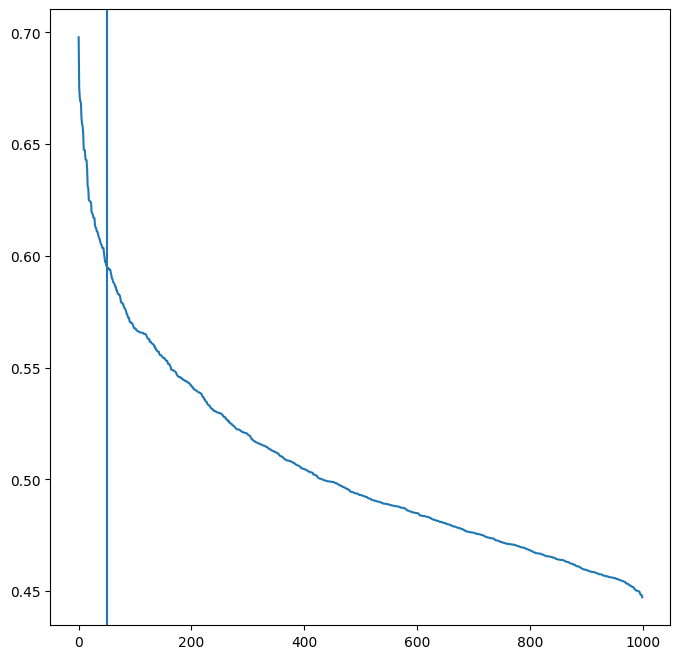

In [36]:
IF = IsolationForest(n_jobs=-1, random_state=42, contamination=0.05)
labels = IF.fit_predict(prep_train_df)
anomaly_score = - IF.score_samples(prep_train_df)   # high values = anomalous
anomaly_score = np.sort(anomaly_score)[::-1]

train_df['IF_anomaly_score'] = (labels == -1).astype(int)
train_df

plt.figure(figsize=(8,8))
plt.plot(anomaly_score)
plt.axvline(x=50)
plt.show()

- very smooth line, not good sign
- try to PCA and plot

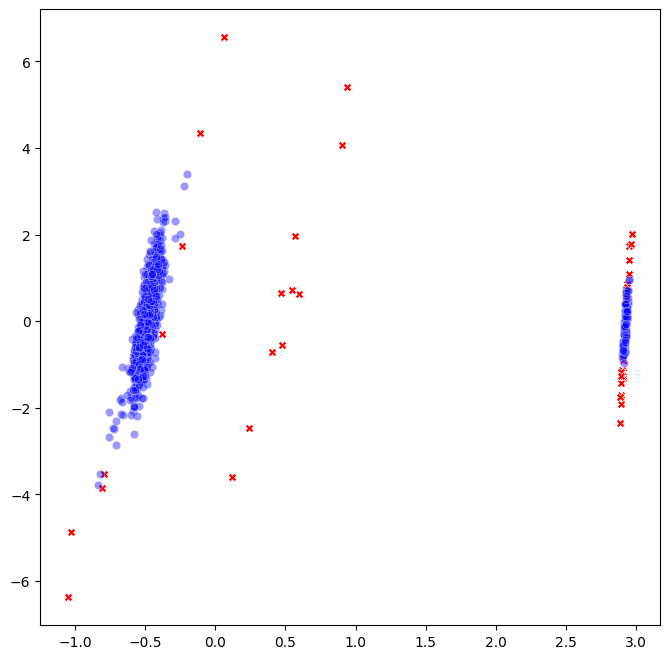

In [39]:
pca = PCA(n_components=2, random_state=42)
pca_data_2D = pca.fit_transform(prep_train_df)

anomaly_idx = train_df[train_df['IF_anomaly_score'] == 1].index
normal_idx = train_df[train_df['IF_anomaly_score'] == 0].index

anomaly_2D = pca_data_2D[anomaly_idx, :]
normal_2D = pca_data_2D[normal_idx, :]

plt.figure(figsize=(8,8))
sns.scatterplot(x=anomaly_2D[:,0], y=anomaly_2D[:,1], c='red', marker='X')
sns.scatterplot(x=normal_2D[:,0], y=normal_2D[:,1], c='blue', alpha=0.4)
plt.show()


- try other and do the same, you get the drill